In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Set random seed for reproducibility
torch.manual_seed(42)

# Define hyperparameters
num_epochs = 10
batch_size = 64
learning_rate = 0.001

# Load and preprocess MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transform,
    download=True
) 

test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model, loss function and optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
def train():
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
                running_loss = 0.0

# Testing function
def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')

# Run training and testing
if __name__ == '__main__':
    train()
    test()

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 92.9kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 903kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.30MB/s]


Epoch [1/10], Step [100/938], Loss: 0.6658
Epoch [1/10], Step [200/938], Loss: 0.1993
Epoch [1/10], Step [300/938], Loss: 0.1448
Epoch [1/10], Step [400/938], Loss: 0.1218
Epoch [1/10], Step [500/938], Loss: 0.1010
Epoch [1/10], Step [600/938], Loss: 0.1099
Epoch [1/10], Step [700/938], Loss: 0.0822
Epoch [1/10], Step [800/938], Loss: 0.0874
Epoch [1/10], Step [900/938], Loss: 0.0835
Epoch [2/10], Step [100/938], Loss: 0.0763
Epoch [2/10], Step [200/938], Loss: 0.0610
Epoch [2/10], Step [300/938], Loss: 0.0575
Epoch [2/10], Step [400/938], Loss: 0.0694
Epoch [2/10], Step [500/938], Loss: 0.0659
Epoch [2/10], Step [600/938], Loss: 0.0714
Epoch [2/10], Step [700/938], Loss: 0.0555
Epoch [2/10], Step [800/938], Loss: 0.0574
Epoch [2/10], Step [900/938], Loss: 0.0491
Epoch [3/10], Step [100/938], Loss: 0.0465
Epoch [3/10], Step [200/938], Loss: 0.0443
Epoch [3/10], Step [300/938], Loss: 0.0477
Epoch [3/10], Step [400/938], Loss: 0.0493
Epoch [3/10], Step [500/938], Loss: 0.0468
Epoch [3/10

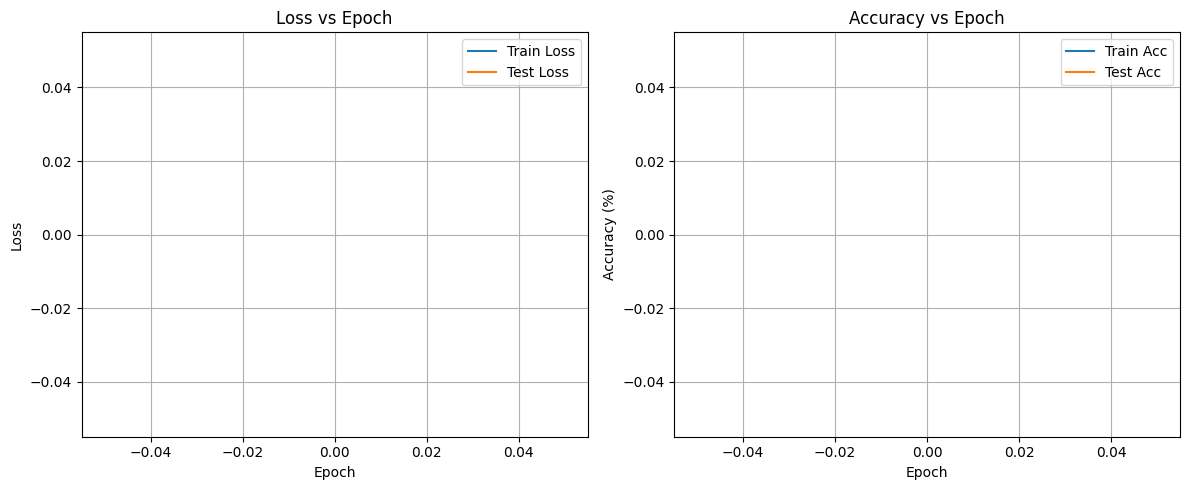

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(1, len(train_accs)+1), train_accs, label='Train Acc')
plt.plot(range(1, len(test_accs)+1), test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()